# Predict Survival from Measured Concentrations

This notebook predicts bacterial survival probabilities from fitted concentration profiles by:
1. Loads HQNO and RHL concentration fit parameters
2. Loads survival model parameters from batch survival experiments
3. Calculates survival probabilities using logistic regression models

Uncertainty of model predictions are determined by exhaustively sampling all possible combinations of fitted concentration gradients. This approach is compared to bootstrap resampling of individual parameters (thus ignoring paired nature of parameter estimates) which gives qualitatively same result.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import json
import sys
sys.path.append(str(Path.cwd().parent / '0_plot_functions'))
from plot_publication_figures import plot_dual_axis_percentiles
from scipy.stats import ecdf

def uptake_diffusion_sinh(x, c0, L, A):
    """
    Calculates numerically stable uptake–diffusion concentration profile, assuming zero boundary condition at x=L.

    Parameters:
    - x: array-like, positions along the gradient
    - c0: float, maximum concentration at x=0
    - L: float, length of the domain
    - A: float, uptake/diffusion rate [1/m^2]

    Returns:
    - c: array-like, concentration at positions x
    c(x) = c0 * sinh(sqrt(A)*(L - x)) / sinh(sqrt(A)*L)

    """
    sA = np.sqrt(A)
    return c0 * np.sinh(sA * (L - x)) / np.sinh(sA * L)

def inv_logit(z):
    z = np.asarray(z, dtype=float)
    return 1.0 / (1.0 + np.exp(-z))

def predict_survival(conc_h, conc_r, model_params):
    """
    Predict survival probability given concentration and model parameters.
    
    Parameters:
    - conc_h: array-like, concentrations of hqno
    - conc_r: array-like, concentrations of rhl
    - model_params: dict, parameters of the logistic regression model with keys 'm_rhl', 'm_hqno', and 'b'
    
    Returns:`
    - survival_probs: array-like, predicted survival probabilities
    """

    m_rhl  = float(model_params["m_rhl"])
    m_hqno = float(model_params["m_hqno"])
    b      = float(model_params["b"])

    rz = m_rhl  * conc_r  + m_hqno * conc_h + b
    survival_probs = inv_logit(rz)
    
    return survival_probs

def create_concentration_profile(df, x_vals):
    """
    Generate concentration profiles for all replicates at specified x positions.
    
    Parameters:
    - df: DataFrame containing fit parameters (c0, L, A) and unique_id
    - x_vals: array-like, positions along the gradient where concentrations are calculated
    
    Returns:
    - conc_profiles: DataFrame with columns 'unique_id', 'x', and 'concentration'
    """
    conc_profiles_list = []
    for _, row in df.iterrows():
        unique_id = row['unique_id']
        c0 = row['c0']
        L = row['L']
        A = row['A']
        c_x = uptake_diffusion_sinh(x_vals, c0, L, A)
        conc_profile = {
            'unique_id': unique_id,
            'y_um': x_vals,
            'concentration': c_x,
        }
        conc_profiles_list.append(conc_profile)

    conc_profiles = pd.DataFrame(conc_profiles_list).explode(['y_um', 'concentration']).reset_index(drop=True)
    return conc_profiles

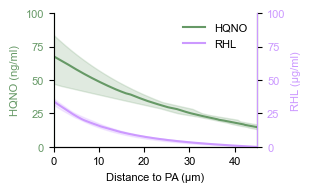

[info] Plotted HQNO (left axis) and RHL (right axis) with percentile bands


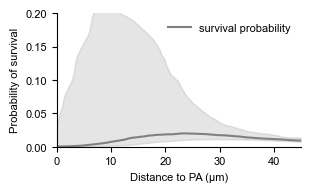

[info] Plotted predicted survival with 25-75 percentile bands


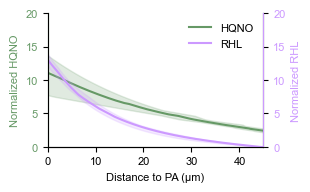

[info] Plotted HQNO (left axis) and RHL (right axis) with percentile bands


In [12]:
# Paths to data files
HQNO_CSV = Path.cwd().parent / '2_gradient_inference' / 'data' / '2_hqno_diffusion_model_fits.csv'
RHL_CSV = Path.cwd().parent / '2_gradient_inference' / 'data' / '2_rhl_diffusion_model_fits.csv'
SURVIVAL_JSON = Path.cwd().parent / '3_batch_survival' / 'data' / 'survival_model_parameters.json'

# ——— figure style ———
final_width_cm = 8    # width in cm
final_height_cm = 5   # height in cm
final_width_in = final_width_cm / 2.54
final_height_in = final_height_cm / 2.54
font_size = 8  # points
plt.rcParams.update({
    'font.size': font_size,
    'font.family': 'Arial',
    'axes.labelsize': font_size,
    'axes.titlesize': font_size,
    'xtick.labelsize': font_size,
    'ytick.labelsize': font_size,
    'legend.fontsize': font_size,
    'pdf.fonttype': 42,
    'ps.fonttype': 42
})

# HQNO color (green)
hqno_color = '#669966'

# RHL color (purple)
rhl_color = '#cc99ff'

# --- Load data ---
df_hqno_fit = pd.read_csv(HQNO_CSV)
df_rhl_fit = pd.read_csv(RHL_CSV)

# Create unique IDs
df_hqno_fit['unique_id'] = df_hqno_fit['replicate'].astype(str) + '_' + df_hqno_fit['pos'].astype(str)
df_rhl_fit['unique_id'] = df_rhl_fit['replicate'].astype(str) + '_' + df_rhl_fit['pos'].astype(str)

# Load parameters of fitted survival models
with open(SURVIVAL_JSON, "r", encoding="utf-8") as f:
    cfg = json.load(f)

# use parameters of the 'hqno_max_60' model as this fits the empirical concentration ranges best
model_params = cfg['hqno_max_60']['parameters']

# Generate high-resolution fitted curves for plotting
y_fit = np.linspace(0, 45, 181)
df_hqno = create_concentration_profile(df_hqno_fit, y_fit)
df_rhl = create_concentration_profile(df_rhl_fit, y_fit)

# --- Predict survival probabilities directly from measured concentrations ---
n_rep_h = len(df_hqno['unique_id'].unique())
n_rep_r = len(df_rhl['unique_id'].unique())
pred_survival = []


# Calculate survival probabilities using exhaustive empirical sampling of concentration profiles to estimate variability
for i in range(n_rep_h):
    for j in range(n_rep_r):
        conc_hqno = df_hqno[df_hqno['unique_id'] == df_hqno['unique_id'].unique()[i]][ 'concentration'].values
        conc_rhl = df_rhl[df_rhl['unique_id'] == df_rhl['unique_id'].unique()[j]][ 'concentration'].values

        y_hqno = df_hqno[df_hqno['unique_id'] == df_hqno['unique_id'].unique()[i]][ 'y_um'].values
        y_rhl = df_rhl[df_rhl['unique_id'] == df_rhl['unique_id'].unique()[j]][ 'y_um'].values

        if not np.array_equal(y_hqno, y_rhl) or len(y_hqno) == 0 or len(y_rhl) == 0:
            raise ValueError('y positions of hqno and rhl do not match!')

        survival_prob = predict_survival(conc_hqno, conc_rhl, model_params)

        output = {
            'hqno_id': df_hqno['unique_id'].unique()[i],
            'rhl_id': df_rhl['unique_id'].unique()[j],
            'unique_id': f"{df_hqno['unique_id'].unique()[i]}_{df_rhl['unique_id'].unique()[j]}",
            'y_um': y_hqno,
            'conc_hqno': conc_hqno,
            'conc_rhl': conc_rhl,
            'predicted_survival': survival_prob
        }

        pred_survival.append(output)

df_pred_survival = pd.DataFrame(pred_survival).explode(['y_um', 'conc_hqno', 'conc_rhl', 'predicted_survival'])

# --- Plot measured concentration gradients ---
left_data = [{
    'df': df_hqno,
    'y_col': 'concentration',
    'label': 'HQNO',
    'color': hqno_color,
    'ylabel': 'HQNO (ng/ml)',
    'ylim': (0, 100),
    'yticks': np.linspace(0, 100, 5)
}]

right_data = [{
    'df': df_rhl,
    'y_col': 'concentration',
    'label': 'RHL',
    'color': rhl_color,
    'ylabel': 'RHL (µg/ml)',
    'ylim': (0, 100),
    'yticks': np.linspace(0, 100, 5)
}]

x_config = {
    'xlabel': "Distance to PA (µm)",
    'xlim': (0, 45)
}

fig, ax = plot_dual_axis_percentiles(
    left_axis_data=left_data,
    right_axis_data=right_data,
    x_col='y_um',
    x_config=x_config,
    percentiles=[25, 50, 75],
    figsize=(final_width_in, final_height_in),
    font_size=font_size
)

# Save outputs
plt.savefig(f'./figures/2_fitted_concentrations.pdf', dpi=300, transparent=True)
plt.show()

print(f"[info] Plotted HQNO (left axis) and RHL (right axis) with percentile bands")


# --- plot predicted survival from conc ---
left_data = [{
    'df': df_pred_survival,
    'y_col': 'predicted_survival',
    'label': 'survival probability',
    'color': 'grey',
    'ylabel': 'Probability of survival',
    'ylim': (0, 0.2),
    'yticks': np.linspace(0, 0.2, 5)
}]

x_config = {
    'xlabel': "Distance to PA (µm)",
    'xlim': (0, 45)
}

fig, ax = plot_dual_axis_percentiles(left_axis_data=left_data, 
                                        x_col='y_um', x_config=x_config, 
                                        percentiles=[25, 50, 75],   
                                        figsize=(final_width_in, final_height_in),
                                        font_size=font_size)


# Save outputs
plt.savefig(f'./figures/2_predicted_survival.pdf', dpi=300, transparent=True)
plt.show()

print(f"[info] Plotted predicted survival with 25-75 percentile bands")

# --- Plot measured concentration gradients, rescaled with logit model parameters ---

df_hqno['scaled_conc'] = model_params['m_hqno'] * df_hqno['concentration']
df_rhl['scaled_conc'] = np.abs(model_params['m_rhl']) * df_rhl['concentration']

left_data = [{
    'df': df_hqno,
    'y_col': 'scaled_conc',
    'label': 'HQNO',
    'color': hqno_color,
    'ylabel': 'Normalized HQNO',
    'ylim': (0, 20),
    'yticks': np.linspace(0, 20, 5)
}]

right_data = [{
    'df': df_rhl,
    'y_col': 'scaled_conc',
    'label': 'RHL',
    'color': rhl_color,
    'ylabel': 'Normalized RHL',
    'ylim': (0, 20),
    'yticks': np.linspace(0, 20, 5)
}]

x_config = {
    'xlabel': "Distance to PA (µm)",
    'xlim': (0, 45)
}

fig, ax = plot_dual_axis_percentiles(
    left_axis_data=left_data,
    right_axis_data=right_data,
    x_col='y_um',
    x_config=x_config,
    percentiles=[25, 50, 75],
    figsize=(final_width_in, final_height_in),
    font_size=font_size
)

# Save outputs
#plt.savefig(f'./figures/2_fitted_normalized_concentrations.pdf', dpi=300, transparent=True)
plt.show()

print(f"[info] Plotted HQNO (left axis) and RHL (right axis) with percentile bands")


Max predicted survival: 0.0199
Total predicted survival: 0.0121


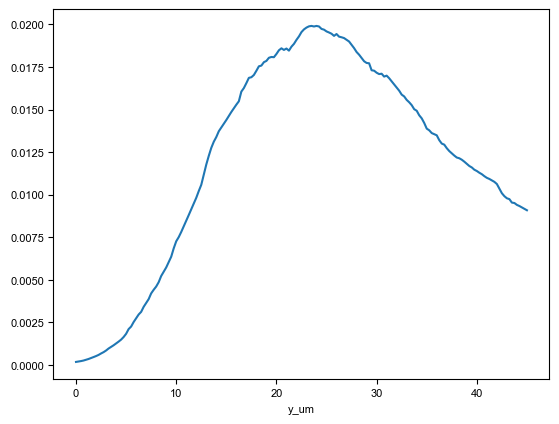

In [4]:
med_survival = df_pred_survival.groupby('y_um')['predicted_survival'].median()
med_survival.plot()

max_survival = med_survival.max()
total_survival = med_survival.mean()

print(f"Max predicted survival: {max_survival:.4f}")
print(f"Total predicted survival: {total_survival:.4f}")

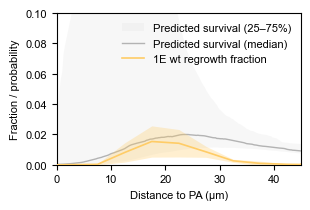

[info] Overlay plot generated using regrowth data from: /Users/giuliabottacin/Desktop/Spatial-Tolerance-Figure-Data-and-Code-main/Figure1/1E_wt/figure_code/1_regrowth_fractions_wt_merged.csv


In [11]:
# --- Overlay predicted survival with 1E wt regrowth fraction (style matched to 2_plot_1E_wt) ---
regrowth_csv_candidates = [
    Path.cwd() / 'figure_code' / '1_regrowth_fractions_wt_merged.csv',
    Path.cwd().parent / 'Figure1' / '1E_wt' / 'figure_code' / '1_regrowth_fractions_wt_merged.csv',
    Path('/Users/giuliabottacin/Desktop/Spatial-Tolerance-Figure-Data-and-Code-main/Figure1/1E_wt/figure_code/1_regrowth_fractions_wt_merged.csv')
]

regrowth_csv = next((p for p in regrowth_csv_candidates if p.exists()), None)
if regrowth_csv is None:
    raise FileNotFoundError(
        'Could not find 1_regrowth_fractions_wt_merged.csv in expected locations. '
        'Please update regrowth_csv_candidates with the correct path.'
    )

df_regrowth = pd.read_csv(regrowth_csv)
reg_y = df_regrowth[df_regrowth['axis'].str.lower() == 'y'].copy().sort_values('bin_left')

# Match 2_plot_1E_wt style: infer bin centers and extend first/last values to plot edges
x_max = 45.0
if len(reg_y) > 1:
    bin_width = float(np.median(np.diff(reg_y['bin_left'].values)))
else:
    bin_width = x_max

centers_y = reg_y['bin_left'].values + bin_width / 2.0
means_y = reg_y['mean_regrowth_fraction'].values
stds_y = reg_y['std_regrowth_fraction'].values


def extend_to_edges(centers, values, left_edge=0.0, right_edge=45.0):
    centers = np.asarray(centers, dtype=float)
    values = np.asarray(values, dtype=float)

    if len(centers) < 2:
        x = np.array([left_edge, centers[0], right_edge])
        y = np.array([values[0], values[0], values[0]])
        return x, y

    m_left = (values[1] - values[0]) / (centers[1] - centers[0])
    left_val = values[0] - m_left * (centers[0] - left_edge)

    m_right = (values[-1] - values[-2]) / (centers[-1] - centers[-2])
    right_val = values[-1] + m_right * (right_edge - centers[-1])

    x = np.concatenate(([left_edge], centers, [right_edge]))
    y = np.concatenate(([left_val], values, [right_val]))
    return x, y

x_line_y, mean_line_y = extend_to_edges(centers_y, means_y, left_edge=0.0, right_edge=x_max)
_, std_line_y = extend_to_edges(centers_y, stds_y, left_edge=0.0, right_edge=x_max)
std_line_y[0] = stds_y[0]
std_line_y[-1] = stds_y[-1]

pred_summary = (
    df_pred_survival.groupby('y_um')['predicted_survival']
    .agg(
        median='median',
        q25=lambda s: s.quantile(0.25),
        q75=lambda s: s.quantile(0.75)
    )
    .reset_index()
)

fig, ax = plt.subplots(figsize=(final_width_in, final_height_in))

ax.fill_between(
    pred_summary['y_um'],
    pred_summary['q25'],
    pred_summary['q75'],
    color='#d9d9d9',
    alpha=0.20,
    linewidth=0,
    zorder=1,
    label='Predicted survival (25–75%)'
)
ax.plot(
    pred_summary['y_um'],
    pred_summary['median'],
    color='#b3b3b3',
    linewidth=1.0,
    zorder=2,
    label='Predicted survival (median)'
)

color_wt = '#ffcc66'
ax.plot(x_line_y, mean_line_y, color=color_wt, linewidth=1.2, zorder=3, label='1E wt regrowth fraction')
ax.fill_between(
    x_line_y,
    mean_line_y - std_line_y,
    mean_line_y + std_line_y,
    color=color_wt,
    alpha=0.3,
    linewidth=0,
    zorder=2
)

ax.set_xlabel('Distance to PA (µm)')
ax.set_ylabel('Fraction / probability')
ax.set_xlim(0, x_max)
ax.set_ylim(0, 0.1)
ax.legend(frameon=False)

plt.savefig('./figures/2_predicted_survival_vs_1Ewt_regrowth.pdf', dpi=300, transparent=True)
plt.show()

print(f'[info] Overlay plot generated using regrowth data from: {regrowth_csv}')